<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/2026.04/Lab4_PE_keithley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect

v0.2.0 Automated measurements

In [50]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c

#Volt-ampere curve


In [51]:
def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            if -1 < root < 0: # only voltages in -1 .. 0 V
               roots.append(root)
    return roots[0]


# Dark current

Text(0, 0.5, 'Current, nA')

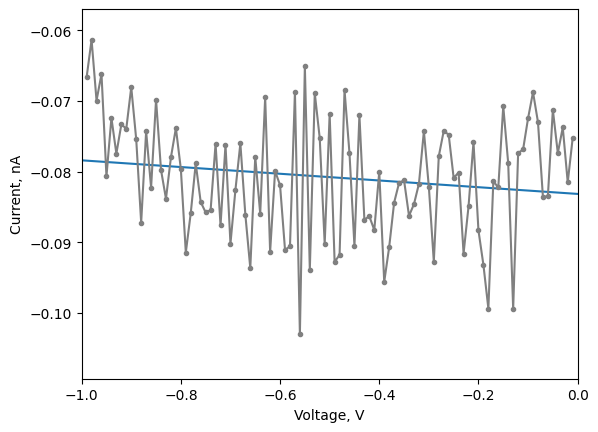

In [52]:
name = 'green'
# dark current
url = f'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.05/{name}_20260503.csv'
LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(url, delimiter=',', skip_header=1, unpack=True)
mask0 = (LED_V == 1) & (-1 < V_set) & (( V_set < 0)) # ambient light
fitdark = linregress(V_set[mask0], I_avg_A[mask0])
dark = lambda x: (fitdark.slope * x + fitdark.intercept)
V = np.linspace(np.min(V_set), np.max(V_set), 100)
plt.plot(V, dark(V)*1e9)
plt.plot(V_set[mask0], I_avg_A[mask0]*1e9, color='gray', marker='.')
plt.xlim(-1, 0)
plt.xlabel('Voltage, V')
plt.ylabel('Current, nA')


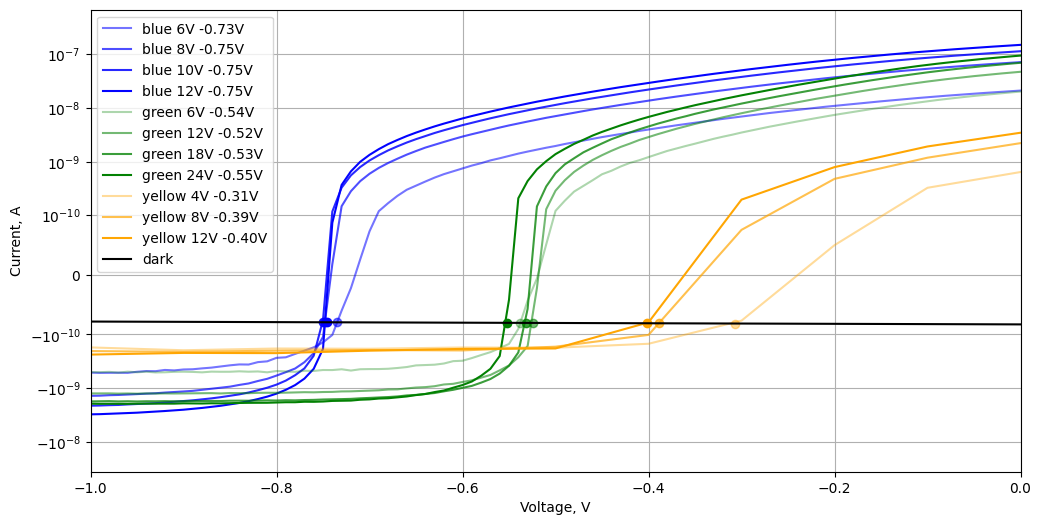

In [53]:
names = ['blue', 'green', 'yellow']
waves = [456, 525, 592]
colors = ['blue', 'green', 'orange']

fig, ax = plt.subplots(figsize=(12,6))

data = '# color wavelength power V0\n'

for i, name in enumerate(names):
  color= colors[i]
  url = f'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.05/{name}_20260503.csv'
  txt = requests.get(url).text
  LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(txt.splitlines(), \
                                                    delimiter=',', skip_header=1, unpack=True)

  powers = np.unique(LED_V)

  for power in powers:
    if power == np.min(powers):
      continue
    if power == 1:
      continue
    mask = (LED_V == power)
    V = V_set[mask]
    I = I_avg_A[mask]
    V0 = find_roots(V, I - dark(V))
    #V0 = find_roots(V, I)
    opacity = 0.1 + 0.89 * (power - np.min(powers)) / (np.max(powers) - np.min(powers))
    plt.plot(V0, dark(V0), color=color, alpha = opacity, marker='o')
    plt.plot(V, I, color=color, alpha=opacity, label=f'{name} {power:.0f}V {V0:.2f}V')
    data += f'{i} {waves[i]} {power:.0f} {-V0:.3f}\n'

    #plt.annotate(f'V0 = {V0:.2f} V', (V0, 0))
    #print(f'{name}, LED:{power:.0f}V, Cut-off {V0:.2f}')

plt.grid()
plt.plot(V, dark(V), color='black', label='dark')
plt.legend()
plt.xlim(-1,0)
#plt.ylim(-1e-10, 1e-8)

plt.xlabel('Voltage, V')
plt.ylabel('Current, A')
plt.yscale('symlog', linthresh=1e-10)
plt.show()


In [54]:
print(data)

# color wavelength power V0
0 456 6 0.735
0 456 8 0.748
0 456 10 0.750
0 456 12 0.746
1 525 6 0.538
1 525 12 0.524
1 525 18 0.531
1 525 24 0.552
2 592 4 0.307
2 592 8 0.388
2 592 12 0.401



# Plank's constant and Work potential determination

$$
 e V_0(\nu) = h \nu -  e W
$$

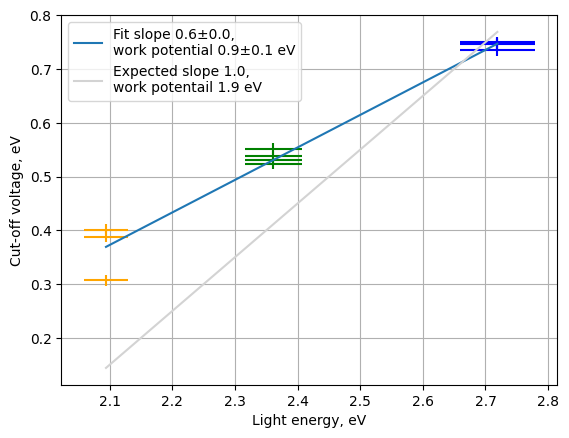

In [55]:
def linear(energy, slope, offset):
    return slope * energy / e - offset


ix, wl, power, V0 = np.genfromtxt(data.splitlines()).T


relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
V_err = 0.01 # V
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset

popt, pcov = curve_fit(linear, energy , V0)
slope = popt[0]
offset = popt[1]
errs = np.sqrt(np.diag(pcov))
slope_err = errs[0]
offset_err = errs[1]
offset_expected = 1.95 # for Cs-Sb Photocathode
for i in range(len(V0)):
  ind = int(ix[i])
  plt.errorbar(energy[i], V0[i], yerr=V_err, xerr=energy_err[i], ls='', color=colors[ind])

plt.plot(energy, -offset + slope * energy / e, label=f'Fit slope {slope/e:.1f}±{slope_err:.1f},\nwork potential {offset:.1f}±{offset_err:.1f} eV')
plt.plot(energy, - offset_expected +  energy , color='lightgray', label=f'Expected slope 1.0,\nwork potentail {offset_expected:.1f} eV')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel('Light energy, eV')
plt.ylabel('Cut-off voltage, eV')
#plt.xlim(0.2, 1)
plt.show()

